# MNIST
## 機械学習のHello World、MNISTの概要
手書き画像の認識を行います。

1枚の画像は28x28ピクセルのグレースケールとなります。

画像の例：<BR> 
<img src="https://drive.google.com/uc?export=view&id=1xrJpQsMcmYjKEc2Chrl5q0hXSWCRfPLG" width=30% alt="fig1_01.png">

 このハンズオンでは、手書き数字の画像が何であるか予測するモデルを開発します。<BR>
  
 例：手書き数字の画像6を入力し、”6”と予測<BR>
 <img src="https://drive.google.com/uc?export=view&id=1dVYyiVoy62xSWaiMAn2unkBo7Bt2_Tfh" alt="fig1_07.png">
<BR>
 
  まずは必要なライブラリをimportします。  
  次のコードセルを実行してください。
  

In [2]:
#機械学習ライブラリの導入
!pip install tensorflow
!pip install matplotlib
!pip install seaborn


In [3]:
# import文、from文ににて必要なライブラリを読み込んでおく
# 手書き文字の画像データセットは、mnistライブラリが保有しているのでimport
from tensorflow.keras.datasets import mnist
# 表示用のライブラリ
import matplotlib.pyplot as plt
# 行列操作のためのライブラリ
import pandas as pd
# 可視化のためのライブラリ
import seaborn as sns
# Kerasでニューラルネットを定義するためのライブラリ
from tensorflow.keras.models import Sequential
# Kerasの最適化関数
from tensorflow.keras.optimizers import Adam
# Kerasの最適化関数
from tensorflow.keras.optimizers import RMSprop
# Denseは全結合ネットワーク、Dropoutはいくつかのノードを停止させる
from tensorflow.keras.layers import Dense, Dropout
# One-hotベクトルを作るための関数
from keras.utils.np_utils import to_categorical
# 行列演算のためのライブラリ
import numpy as np
# 混同行列表示用のライブラリ
from sklearn.metrics import confusion_matrix
# notebook内での図表のインライン表示を行うための指定
#%matplotlib inline

2022-12-11 08:28:21.866226: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2022-12-11 08:28:21.866293: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2022-12-11 08:28:21.866300: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Cannot dlopen some TensorRT libraries. If you would like to use Nvidia GPU with TensorRT, please make sure the missing libraries mentioned above are installed properly.


## MNISTデータセットの構造
MNISTのデータセットは次のようになっています。

*   学習データ 60,000件(画像60,000件、ラベル60,000件)
*   検証データ 10,000件(画像10,000件、ラベル10,000件)

<img src="https://drive.google.com/uc?export=view&id=1RQ6tlFIzWKOaSAdaBpvC1frRwE0eZrfa" width=50% alt="fig1_03.png">

## MNISTデータセットのロードを行います


```
(x_train, y_train), (x_test, y_test) = mnist.load_data()
```

この関数から４つの変数を２組のタプルとして得ます。<BR>
最初のカッコ(x_train, y_train)に学習データが読み込まれます。<BR>
次のカッコ(x_test, y_test)には検証データが読み込まれます。<BR>

*   x_trainには画像データ(60,000枚)
*   y_trainには画像の数字が何であるかを示す正解の数字(60,000個)
*   x_testには画像データ(10,000枚)
*   y_testには画像の数字が何であるかを示す正解の数字(10,000個)
 
<BR>
x_trainとy_trainは１対１のペア(画像と数字)になりますので、<BR>
(x_train, y_train)という形で２コイチで応答されます。<BR>
この記述はpythonではタプルと読んでいます。<BR>
同様にx_test, y_testもペアになっています。<BR>
<BR>
 画像とラベルの例：<BR>

<img src="https://drive.google.com/uc?export=view&id=1qsOVUDvuuMvUmBU19CJQ2ZWbDkSHVZ2A" width=40% alt="fig1_02.png">
<BR>
では、データを読み込んでみましょう。次のコードセルを実行します。
  
参考：タプルはリストを保持します。通常のリストと違うのは変更ができない点となります。

In [4]:
#データのロード
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [5]:
#データの形式を確認
# x_trainに60,000件の手書き画像データ、サイズは28x28ピクセル（学習データとして使う）
# y_trainにラベル
# x_testに10,000件の手書き画像データ、サイズは28x28ピクセル（検証データとして使う）
# y_testにラベル
print('x_train.shape:{}'.format(x_train.shape))
print('y_train.shape:{}'.format(y_train.shape))
print('x_test.shape:{}'.format(x_test.shape))
print('y_test.shape:{}'.format(y_test.shape))

x_train.shape:(60000, 28, 28)
y_train.shape:(60000,)
x_test.shape:(10000, 28, 28)
y_test.shape:(10000,)


In [6]:
print('len(x_train)={}'.format(len(x_train)))
print('len(x_train[0])={}'.format(len(x_train[0])))
print('len(x_train[0][0])={}'.format(len(x_train[0][0])))


len(x_train)=60000
len(x_train[0])=28
len(x_train[0][0])=28


1番目のラベル = 5


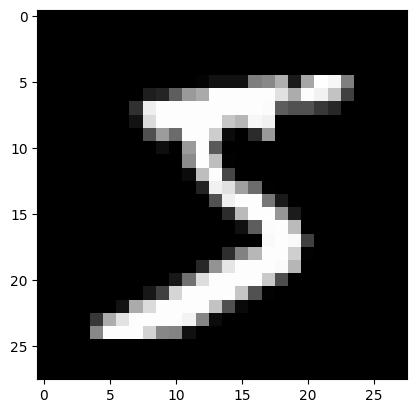

In [7]:
#最初のラベルと画像を表示(データセットの１件目は５になっています)
#numは、何番目の画像を表示するか指定します。（番号を変えて他の画像も試してみましょう）
num=0
print('{}番目のラベル = {}'.format(num+1, y_train[num]))
#画像の表示、plt.imshowで表示します、引数は順に画像データ(x_train)、cmapにグレースケールであることを指定します。
#縦28ピクセル、横28ピクセルの画像であることが分かります。
plt.imshow(x_train[num], cmap=plt.get_cmap('gray'))

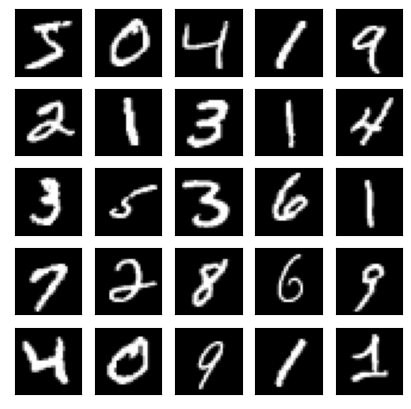

In [9]:
#参考までに25件の画像を表示してみる
w = 5
h = 5
#図表示のための5x5の描画エリアを準備しfigに確保
fig = plt.figure(figsize=(w, h))
#確保したfigの描画エリアに対して順に画像を割り当てて表示を行う
#xticks, yticksはx軸、y軸に対するメモリです。
#メモリをつけないため、xticks=[]と書いています。
#xticks=[0,10,20,28]とするとメモリが該当ピクセル位置に表示されますので、変更して確認してみましょう。
#x_trainは縦横２次元の学習データ(画像)です。
#cmapはカラーマップ指定で、ここではグレースケール指定を行なっています。

for i in range(w*h):
    ax = fig.add_subplot(w, h, i + 1, xticks=[], yticks=[])
    ax.imshow(x_train[i], cmap='gray')

In [10]:
#ピクセルデータが28x28の 2次元データのため1次元(要素数784)に配列の形状を変換する。
#これは、ニューラルネットが受け取る次元に合わせるため
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

In [11]:
#データの分布を確認するため配列データをPadasの形式に変換する
pd_y_train =  pd.Series(y_train)

In [12]:
#数字0〜9それぞれに何件あるか、ラベル毎にカウントし確認します。
#偏りが無いことが確認できます。
#偏りがある場合は、学習データが均一となるよう調整する方が良いでしょう。
pd_y_train.value_counts(sort=False)

5    5421
0    5923
4    5842
1    6742
9    5949
2    5958
3    6131
6    5918
7    6265
8    5851
dtype: int64

In [14]:
#データの正規化
#画像のピクセルデータは0〜255の範囲を取る値となっていますので、0〜1に正規化を行い、
#学習が速く収束するようします。
x_train = x_train / 255.0
x_test = x_test / 255.0

## One-hotベクトルの作成
One-hotベクトルは、あるインデックスが１となり残りが０となるベクトルです。<BR>
今回の0〜9までの識別(分類)を行う場合、次のように作成します。<BR>
<BR>
例：5の場合は、該当する箇所に1を立てます。→ [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]<BR>
 1→[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]<BR>
 2→[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]<BR>
 3→[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]<BR>
  

In [15]:
#正解ラベルは0〜9の数字となっているため、Kerasのユーティリティto_categorical関数によって
#One-Hotベクトルにエンコードし教師データとします
y_train = to_categorical(y_train, num_classes = 10)
y_test = to_categorical(y_test, num_classes = 10)

In [16]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=float32)

In [17]:
#試しに１件目のone-hotベクトルを表示してみます。
#１件目は５のためインデックス５の部分が１になります。
print(y_train[1])

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [18]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.], dtype=float32)

## バッチサイズと学習回数について
### バッチサイズ
バッチサイズはディープラーニングで言われているハイパーパラメータの一つとなります。<BR>
ハイパーパラメータはディープラーニングにおいて設定可能なのパラメータの総称で、<BR>
バッチサイズはそのひとつとなり、このプログラムでは変数batch_sizeに設定しています。<BR>

```
  batch_size=30
```


この値はデータセットを分割する際の単位となり、下図は60,000件のデータセットに対して、<BR>
バッチサイズに30を設定した場合の例となります。この場合データセットは30個に分割された<BR>
サブセットとなり、各2,000件のデータが格納されます。<BR>
 <BR>
<img src="https://drive.google.com/uc?export=view&id=1cU1gLPLlAxBR8D9i5FQoup4Mte3vkxxo" width=50% alt="fig1_05.png">
<BR>

このサブセットに含めるデータは、データセットから重複なくランダムに抽出されます。<BR>
1回の学習に使うデータをランダムに分割することで、特徴をまんべんなく学習することが<BR>
できます。<BR>
もし、分割を行わずに一度(batch_size=1)に60,000件を対象とすると、特徴として60,000件の<BR>
平均的な値しか得られないため精度の低いモデルができあがります。<BR>
分割することで、小さな単位で特徴を学ぶことができるため、精度の良いモデルが期待できます。<BR>
<BR>
バッチサイズの目安は、まずは大きめにとって学習回ごとの損失関数（コスト関数）の値が<BR>
上がらない(学習が収束しない)ようであれば、バッチサイズを小さくします。<BR>
ただし、バッチサイズが小さくなるほど学習時間を必要とします。<BR>
また、精度向上はバッチサイズだけではなく、他のハイパーパラメータの調整も行いますので、<BR>
それらパラメータと合わせて、調整を行います。<BR>
  
  
 ### 学習回数
学習回数もハイパーパラメータの一つとなり、分割されたサブセットを何回学習させるか決定します。<BR>
学習回数はエポック数とも呼ばれ、このプログラムではepochsに設定しています。<BR>


```
epochs=30
```

1回の学習で分割されたサブセットのデータを一通り使い学習を行います。この例では、30個に分割されて<BR>
いますが、1回の学習でサブセットが全て使われます。このサブセットの学習単位をイテレーションと呼び、<BR>
この例では1回の学習30イテレーションの学習が行われ、これをepochsで指定する学習回数１回と数えます。<BR>
<BR>

<img src="https://drive.google.com/uc?export=view&id=1kLdCk-4f-f1boiNYzBP3dVDk2BdWTxfZ" width=50% alt="fig1_06.png">
<BR>
学習回数の目安として10〜30回くらいを最初に指定して学習を行い、学習回ごとの損失関数（コスト関数）の値が<BR>
収束しないようであれば、値の見直しを行います。<BR>
<BR>
例えば・・・
* 収束がみられず、まだ損失関数の値が小さくできると見込まれる場合は、学習回数を増やします。<BR>
* 逆に損失関数の値が増えていくようであれば、学習回数を減らします。(他のパラメータを見た方が良いかも)<BR>
* 損失関数の値が乱高下するようであれば、学習回数を減らすなどを行います。(他のパラメータを見た方が良いかも)<BR>

注：ただし、上記が必ず正解の方法とも言えません。他のハイパーパラメータを含め変更を行う、またはネットワークの<BR>
構造も見直しなどを行う必要があるかもしれません。<BR>  
<BR>
参考：ハイパーパラメータ以外に考えられるチューニング箇所<BR>
* 学習データが不足している
* 学習データに誤りがある
* ネットワークの層、ノード数が不適切
<BR>

では、コードセルを実行していきましょう。<BR>

In [19]:
batch_size=30
epochs=30

## ニューラルネットの定義

ここでいよいよ、ニューラルネットワークの定義をmodelに対して行います。<BR>
modelは順に層を追加する事で定義を行うSequentialを使います。<BR>

下図は①〜③のadd関数でネットワークの定義を行います。<BR>
ここでは入力層784ノード、中間層(隠れ層)512ノード、出力層(10ノード)を全結合(Dense)ネットワークとして定義します。<BR><BR>
入力層は28x28ピクセルの画像データを入力するため784ノード、出力層は0〜9までの予測を行うため10ノードとなります。<BR>
中間層のノード数は、試して良好なノード数とするのが良いでしょう。<BR>
今回は経験上512ノードとしました。(特に理由なし)<BR>
 <BR>
 下図はプログラムの定義をニューラルネットワークの図に対応させたものとなります。<BR>
 <BR>

<img src="https://drive.google.com/uc?export=view&id=1w8EhlOB08Yse0OOVwwu4Lnui-zRgU-Mh"  alt="fig1_08.png">
<BR>
  
①の活性化関数(activation)として指定しているReLU関数は、破線の囲みのような関数となります。<BR>
この関数が示すようにxが負の値を取るときはゼロを、それ以外はxに入ってきた値を次のノードに渡します。<BR>
ReLU関数は単純な関数ですが、画像認識分野では利用される事が多い関数となります。<BR>
こうした活性化関数は、他にステップ関数、シグモイド関数などがあります。(これらは、後日まとめて解説)<BR>
<BR>
②のDropoutは、学習のたびにランダムで一定数のノードを止めます。(何も出力しない)<BR>
これにより過学習を防止する事ができます。<BR>
過学習は、訓練データには良い精度を示すが、未知のテストデータでは精度が低い状態を指します。<BR>
この状態は訓練データに強く依存した学習状態となっており、汎化性能が著しく低くなっています。<BR>
これを防止する方法として、学習時に一定数のノードをランダム停止させ、残りのノードで特徴を<BR>
つかもことで汎化性能を上げます。ディープラーニングでは有効な手段のひとつとなります<BR><BR>
③の活性化関数(activation)として指定しているsoftmaxは、10個ある出力ノードの値を足して１となる確率として<BR>
出力を行います。<BR>
  
## コンパイル
定義したニューラルネットをコンパイル(compile)によりインスタンス化します。<BR>
 
```
model.compile(optimizer =Adam(lr=0.0001) , loss = 'categorical_crossentropy', 　metrics=['accuracy'])
```

引数で指定している値は下表の通りとなります。<BR>
 
|#|引数|説明|
|--|--|--|
|1|optimizer|予測した出力データと正解データ(教師データ)の誤差を小さくするために行う、ネットワークの重みを調整アルゴリズム<BR>として最適化アルゴリズムであるAdamを指定します。Adamは最も利用される事が多い最適化アルゴリズムです。<BR>Adamに指定している'lr'は学習率となります。この値を小さく取ると小刻みに学習が進むため、より良い最適解を得られるますが<BR>学習に時間がかかります。逆に値を大きくと取ると、学習時間を短くできますが、最適解を飛び越えてしまい最適解が<BR>得られない可能性があります。|
|2|loss|損失関数を指定します。損失関数は推測した出力データと正解データ（教師データ）との誤差を計算する関数となります。<BR>クロスエントロピーはクラス分類における損失関数として利用されるもので、ここではKerasでは多クラス分類のおける<BR>損失関数としてcategorical_crossentropyを指定します。他の例として写っている動物を犬、猫のように分類する２値分類の場合は、<BR>binary_crossentropyを指定します。|
|3|metrics|訓練やテストの際にモデルを評価するための評価関数をリストで指定します。ここでは一般的によく使われる'accuracy'だけを<BR>指定しています。accuracyは予測した値と正解が一致していた数のカウントとなり、どれだけ正解を出しているかの指標となります。|
  
<BR>

In [20]:
#モデルの構築
model = Sequential()
#全結合層、512個のノード、正の領域はそのままにして、マイナスの領域はゼロにするreluを使う
model.add(Dense( units =  512, activation = 'relu', input_shape = ( 784, ) ) )
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))
model.compile(optimizer =Adam(lr=0.0001) , loss = 'categorical_crossentropy',  metrics=['accuracy'])
#モデル定義のサマリを表示する
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               401920    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                5130      
                                                                 
Total params: 407,050
Trainable params: 407,050
Non-trainable params: 0
_________________________________________________________________


## 学習の実施と評価
学習はモデルのfit関数にて実施します。<BR>

```
result = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))
```
下表に引数指定している値について説明します。<BR>

|#|引数|説明|
|--|--|--|
|1|x_train|学習データ(画像)|
|2|y_train|学習データ(正解ラベル)|
|3|batch_size|バッチサイズ|
|4|epochs|エポック数(学習回数)|
|5|validation_data (x_test, y_test)|x_test=検証データ(画像)、y_test=検証データ(正解ラベル)|

 <BR>
また、各エポック毎(学習回毎)に評価指標として損失関数の値(loss)、正確さ(Accuracy)が表示され、これら値はresultにも格納されます。<BR>
resultは学習後に可視化(グラフ)し精度評価を行います。<BR>
今回、使用する評価指標は下表となります。<BR>

|#|評価指標|説明|評価|
|--|--|--|--|
|1|loss|学習データによる損失関数の値|学習を重ねるごとに低くなるのが良い|
|2|accuracy|学習データによる正解率|学習を重ねるごとに高くなるのが良い|
|3|val_loss|検証データによる損失関数の値|学習を重ねるごとに低くなるのが良い、ただし、lossより下回ること|
|4|val_accuracy|検証データによる正解率|学習を重ねるごとに高くなるのが良い、ただし、accuracyを上回ること|

<BR>
検証データのval_lossが学習データよりも悪く(lossを下回らない)、学習を追うごとに差が開く場合は過学習が疑われます。<BR>

   
   


In [21]:
#処理時間計測のため開始時刻を取得
import time
start = time.time()

#学習を行う
result = model.fit(x_train, y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_data=(x_test, y_test))

#処理時間の表示
# 参考：CPUにてかかった時間 elapsed_time:512.9343266487122[sec]
# 参考：GPUにてかかった時間 elapsed_time:204.46984910964966[sec]
elapsed_time = time.time() - start
print ('elapsed_time:{0}'.format(elapsed_time) + '[sec]')

Epoch 1/30
2000/2000 [==============================] - 6s 2ms/step - loss: 0.2686 - accuracy: 0.9200 - val_loss: 0.1271 - val_accuracy: 0.9627
Epoch 2/30
2000/2000 [==============================] - 5s 2ms/step - loss: 0.1397 - accuracy: 0.9575 - val_loss: 0.0906 - val_accuracy: 0.9714
Epoch 3/30
2000/2000 [==============================] - 5s 2ms/step - loss: 0.1113 - accuracy: 0.9653 - val_loss: 0.0721 - val_accuracy: 0.9783
Epoch 4/30
2000/2000 [==============================] - 5s 2ms/step - loss: 0.0942 - accuracy: 0.9703 - val_loss: 0.0727 - val_accuracy: 0.9774
Epoch 5/30
2000/2000 [==============================] - 5s 2ms/step - loss: 0.0818 - accuracy: 0.9743 - val_loss: 0.0710 - val_accuracy: 0.9779
Epoch 6/30
2000/2000 [==============================] - 5s 2ms/step - loss: 0.0740 - accuracy: 0.9764 - val_loss: 0.0687 - val_accuracy: 0.9796
Epoch 7/30
2000/2000 [==============================] - 5s 2ms/step - loss: 0.0661 - accuracy: 0.9785 - val_loss: 0.0782 - val_accuracy:

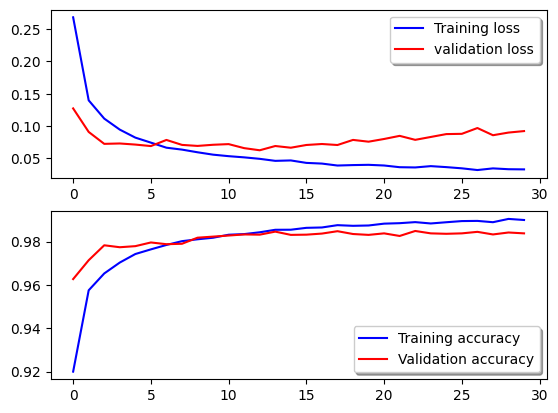

In [22]:
#学習の過程をグラフにて可視化
#上のグラフは損失関数の推移となり、学習が進むにつれて低下するのが望ましい
#下のグラフは正確さで、学習が進むにつれて向上するのが望ましい
fig, ax = plt.subplots(2,1)
ax[0].plot(result.history['loss'], color='b', label="Training loss")
ax[0].plot(result.history['val_loss'], color='r', label="validation loss",axes =ax[0])
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(result.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(result.history['val_accuracy'], color='r',label="Validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)

## 学習済みモデルで予測を行う
### 検証データの表示

まずは学習済みモデルに渡す検証データ(x_tset)のはじめから５個の手書き画像を表示してみます。<BR>
なお、x_testは学習時の評価用に使われたデータを流用しています。このデータは、モデルを<BR>
トレーニングするための学習データとして、学ばせていませんので、学習済みモデルからみて<BR>
未知の手書き画像と言えます。<BR>
  
下のセル実行による手書き画像'7', '2', '1', '0', '4'が表示されます。

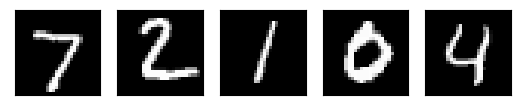

In [23]:
#x_testは10,000件あるため、結果x_predも10,000件となります。
#ここでx_testの画像を先頭から25件表示します。
#x_testはニューラルネットへの入力のため１次元の配列となっています。
#ここでは表示を行うため、28x28の画像データとするため配列の変形(reshape)を行っています。
w = 1
h = 5

fig = plt.figure()

for i in range(w*h):
    ax = fig.add_subplot(w, h, i + 1, xticks=[], yticks=[])
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')

In [24]:
#学習したモデルに対して検証データ(10,000件)を渡し予測を行う
#予測はモデルのpredict関数にて行う。引数として手書き画像の検証データx_testを指定する。
x_pred = model.predict(x_test)

#識別した数字を取得する。
#one-hotベクトルになっているので、１が立っているところの添字を正解ラベルとします。
x_pred_classes = np.argmax(x_pred, axis = 1) 

#最後に混同行例による評価を行うため正解の数字をy_trueに入れておく、こちらも同様にone-hotベクトルか取得
y_true = np.argmax(y_test,axis = 1)

313/313 [==============================] - 0s 1ms/step


In [25]:
x_pred[0]

array([2.0809392e-21, 1.0737443e-22, 4.0012665e-17, 8.0007711e-12,
       9.7445611e-25, 1.6231524e-17, 8.2224504e-31, 1.0000000e+00,
       1.8127607e-18, 2.2031706e-12], dtype=float32)

In [26]:
y_true

array([7, 2, 1, ..., 4, 5, 6])

In [27]:
x_pred_classes[0]

7

## 結果の確認
入力した手書き画像が、何の数字と予測したか確認します。<BR>
確認は出力ノードから得た値(x_pred)を表示してみます。<BR>

<BR>
<img src="https://drive.google.com/uc?export=view&id=13M1ysw63wRghyLlWZJONj95zcJPiEh8v" width=80% alt="fig1_09.png">
<BR>

  
まずは、x_predの１件目に10ノード分の予測結果が格納されているので表示します。<BR>
表示は指数になってしまっているので、この後のセルで表示を変えて確認します。<BR>
```
print('識別結果={}'.format(x_pred[0]))
```
次に、ナムパイのargmax関数を使い、最大値を持つノードの番号を表示させます。<BR>
表示されたノード番号が、予測した数字となります。
```
print('値={}'.format(np.argmax(x_pred[0])))
```


In [28]:
#では、モデルが識別した最初の1件目の結果をみてみましょう。
#"識別結果"にある10個のリストは、出力ノードから得られた値で、　リストの先頭が数字のゼロに対応しています。
#この例で１件目は7番目の要素が一番大きい値となっています。
#このことからモデルでは識別した数字("値")は７となります。

print('識別結果={}'.format(x_pred[0]))
print('値={}'.format(np.argmax(x_pred[0])))

識別結果=[2.0809392e-21 1.0737443e-22 4.0012665e-17 8.0007711e-12 9.7445611e-25
 1.6231524e-17 8.2224504e-31 1.0000000e+00 1.8127607e-18 2.2031706e-12]
値=7


予測結果の表示を分かりやすくし、はじめから５件の手書き画像に対する予測結果を表示させます。<BR>
(max)と表示のあるノード番号が予測した数字となりますので、予測前に表示を行なった、<BR>
手書き画像とあっているか確認してみましょう。<BR>

In [29]:
#最初の5件のノード出力、および最大値なる箇所に(MAX)と表示します。
#なお、ノード出力が指数表記になっていましたので、小数点以下10桁表示を行います。
#２つ前のセルで表示した入力画像とMAX一致しているか確認してみます。
for i in range(5):
    print('{}件目 ---------------------------------------'.format(i+1))
    max = np.argmax(y_test,axis = 1)[i]
    for j in range(10):
        if j == max:
            print('node={}, output={} (MAX)'.format(j, '%.10f' % x_pred[i][j]))
        else:
            print('node={}, output={}'.format(j, '%.10f' % x_pred[i][j]))    

1件目 ---------------------------------------
node=0, output=0.0000000000
node=1, output=0.0000000000
node=2, output=0.0000000000
node=3, output=0.0000000000
node=4, output=0.0000000000
node=5, output=0.0000000000
node=6, output=0.0000000000
node=7, output=1.0000000000 (MAX)
node=8, output=0.0000000000
node=9, output=0.0000000000
2件目 ---------------------------------------
node=0, output=0.0000000000
node=1, output=0.0000000000
node=2, output=1.0000000000 (MAX)
node=3, output=0.0000000000
node=4, output=0.0000000000
node=5, output=0.0000000000
node=6, output=0.0000000000
node=7, output=0.0000000000
node=8, output=0.0000000000
node=9, output=0.0000000000
3件目 ---------------------------------------
node=0, output=0.0000000000
node=1, output=1.0000000000 (MAX)
node=2, output=0.0000000000
node=3, output=0.0000000000
node=4, output=0.0000000000
node=5, output=0.0000000000
node=6, output=0.0000000000
node=7, output=0.0000000007
node=8, output=0.0000000000
node=9, output=0.0000000000
4件目 ------

<AxesSubplot: >

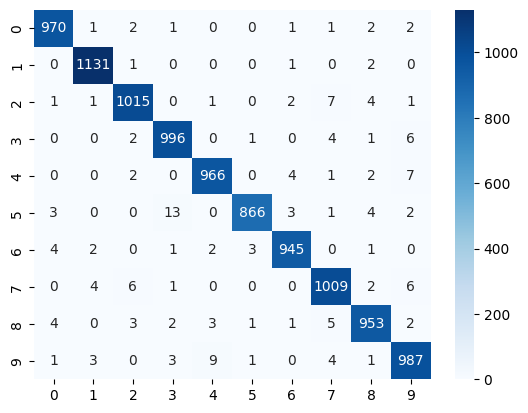

In [30]:
#混同行列を作成し、識別精度の可視化を行います。
#処理はconfusion_matrixに、検証データの正解ラベル(y_true)、検証データの画像が何の数字であるか識別した結果(x_pred_classes)を渡す。
confusion_mtx = confusion_matrix(y_true, x_pred_classes) 

#混同行列を表示する（縦軸：実際の数字、横軸：予測した数字）
#見方として、モデルがゼロとして予測した数字(横軸のゼロ)と、
#実際の正解ラベルの数字(縦軸)のゼロが一致した件数が971件ありました。
#つまり、対角線上の値が高いほど精度が良いいえます。
#また、2と予測した数字は実際は７であったりと、
#2と7は他に比べて、間違いやすいという事がわかります。

sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap=plt.cm.Blues)

## 学習済みモデルの保存と読込
学習済みモデルの保存、読込の基本をまず実行します。<BR>
ただし、この時の保存先が演習プログラムのセッション中しか保持できません。<BR>
このため保存したモデルを永続的に保持するためにGドライブに保存します。<BR>
次の演習として、前半はモデルの保存、読込の基本。続いてGドライブへの保存、読込について学びます。<BR>




In [31]:
#モデルの保存と読込について
#学習済みのモデルを保存する場合は、save関数にてファイル名を指定し保存します。
#この例では簡単ですが、ファイル名を"m.h5"として直下に保存しています。
#なお本演習では保存したファイルはセッション中しか保持されません。(Colabo環境の制約)
#永続して保持するにはGドライブに保管します。

model.save('./mnist.h5')


In [35]:
#モデルの読込
#Kerasのload_model関数にてモデルを読み込みます。
#ここでは、上記で保存したモデルをmnistModelという名前の変数に読み込みます。

import keras
mnistModel = keras.models.load_model('./mnist.h5')


#読み込んだモデルによる予測
pred = mnistModel.predict(x_test)


313/313 [==============================] - 0s 1ms/step
